Libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split

Data Preprocessing and EDA 

In [2]:
# Load dataset
df = pd.read_csv('maib_uk_maritime_accidents_2010_2024.csv')


# Remove duplicates
df = df.drop_duplicates()

# Standardize column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df.head()

,id,location,vessel_type,flag,gross_tonnage,length_(m),port,injury_type,fatalities,description,weather,damage,date
0,d9096ad0-5d16-ee11-9cbe-002248c87217,Coastal waters <= 12 nm,Passenger ship,UNITED KINGDOM,140000.0,330.0,NaN,Bone fractures,0,A cruise ship passenger fell out of bed result...,Clear,No damage,2023-06-01
1,02d9d69b-2f22-ee11-9967-002248c8714f,Internal waters -> Port area,Passenger ship,UNITED KINGDOM,110000.0,290.0,CANADA,Bone fractures,0,Cruise ship's passenger tripped and sustained ...,Clear,No damage,2023-07-01
2,f5131f0e-0127-ee11-9965-002248c87a51,Internal waters -> Port area,Passenger ship,UNITED KINGDOM,8000.0,89.0,UNITED KINGDOM,"Dislocations, sprains and strains",0,A ro-pax crew member sustained a torn rotator ...,Unknown,No damage,2023-07-01
3,3f33abdb-bd6d-ee11-9ae7-002248c8714f,Internal waters -> Port area,Cargo ship,CYPRUS,9900.0,130.0,UNITED KINGDOM,Bone fractures,0,Container ship's crew member sustained an open...,Unknown,No damage,2023-10-01
4,f4c50e53-f9c0-ee11-9079-002248c8714f,Open sea -> Outside EEZ,Passenger ship,UNITED KINGDOM,58000.0,230.0,NaN,Bone fractures,0,A cruise ship passenger fell and sustained a f...,Clear,No damage,2024-01-01


In [3]:
# Extract temporal features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Drop high-cardinality / text columns (not suitable for classical ML)
df = df.drop(columns=['id', 'description', 'date'])

# Handle fatalities as binary indicator (extra feature)
df['fatalities_binary'] = (df['fatalities'] > 0).astype(int)

df.head()


,location,vessel_type,flag,gross_tonnage,length_(m),port,injury_type,fatalities,weather,damage,year,month,fatalities_binary
0,Coastal waters <= 12 nm,Passenger ship,UNITED KINGDOM,140000.0,330.0,NaN,Bone fractures,0,Clear,No damage,2023,6,0
1,Internal waters -> Port area,Passenger ship,UNITED KINGDOM,110000.0,290.0,CANADA,Bone fractures,0,Clear,No damage,2023,7,0
2,Internal waters -> Port area,Passenger ship,UNITED KINGDOM,8000.0,89.0,UNITED KINGDOM,"Dislocations, sprains and strains",0,Unknown,No damage,2023,7,0
3,Internal waters -> Port area,Cargo ship,CYPRUS,9900.0,130.0,UNITED KINGDOM,Bone fractures,0,Unknown,No damage,2023,10,0
4,Open sea -> Outside EEZ,Passenger ship,UNITED KINGDOM,58000.0,230.0,NaN,Bone fractures,0,Clear,No damage,2024,1,0


In [4]:
target_column = 'injury_type'
df_model = df.dropna(subset=[target_column])
total_injuries = df_model.shape[0]
print("Total injuries:", total_injuries)

df_model['injury_type'].value_counts()


Total injuries: 1823


injury_type
Bone fractures                                                                      705
Wounds and superficial injuries                                                     257
Dislocations, sprains and strains                                                   241
Drowning and asphyxiation                                                           204
Concussions and internal injuries (including crush injuries not mentioned above)    159
Unknown or unspecified                                                               73
Traumatic amputations (Loss of body parts)                                           57
Burns, scalds and frostbites                                                         41
Multiple injuries                                                                    29
Other specified injuries not included under other headings                           16
Shock                                                                                13
Effects of temperatu

In [5]:
# Target variable
target_column = 'injury_type'

# Remove rows with missing target values
df_model = df.dropna(subset=[target_column])

# Define features and target
X = df_model.drop(columns=[target_column])
y = df_model[target_column]

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])
print("\nTarget class distribution:")
print(y_train.value_counts())


Training samples: 1458
Test samples: 365

Target class distribution:
injury_type
Bone fractures                                                                      564
Wounds and superficial injuries                                                     206
Dislocations, sprains and strains                                                   193
Drowning and asphyxiation                                                           163
Concussions and internal injuries (including crush injuries not mentioned above)    127
Unknown or unspecified                                                               58
Traumatic amputations (Loss of body parts)                                           46
Burns, scalds and frostbites                                                         33
Multiple injuries                                                                    23
Other specified injuries not included under other headings                           13
Shock                                  

In [6]:
# Identify feature types
categorical_features = X_train.select_dtypes(include=['object']).columns
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('variance', VarianceThreshold(threshold=0.0))
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        min_frequency=0.01
    ))
])

# Column transformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline ready.")


Preprocessing pipeline ready.


In [7]:
# Fit and transform training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

# Check class distribution
print("\nClass distribution (training):")
print(y_train.value_counts(normalize=True))


Processed training shape: (1458, 37)
Processed test shape: (365, 37)

Class distribution (training):
injury_type
Bone fractures                                                                      0.386831
Wounds and superficial injuries                                                     0.141289
Dislocations, sprains and strains                                                   0.132373
Drowning and asphyxiation                                                           0.111797
Concussions and internal injuries (including crush injuries not mentioned above)    0.087106
Unknown or unspecified                                                              0.039781
Traumatic amputations (Loss of body parts)                                          0.031550
Burns, scalds and frostbites                                                        0.022634
Multiple injuries                                                                   0.015775
Other specified injuries not included under other 

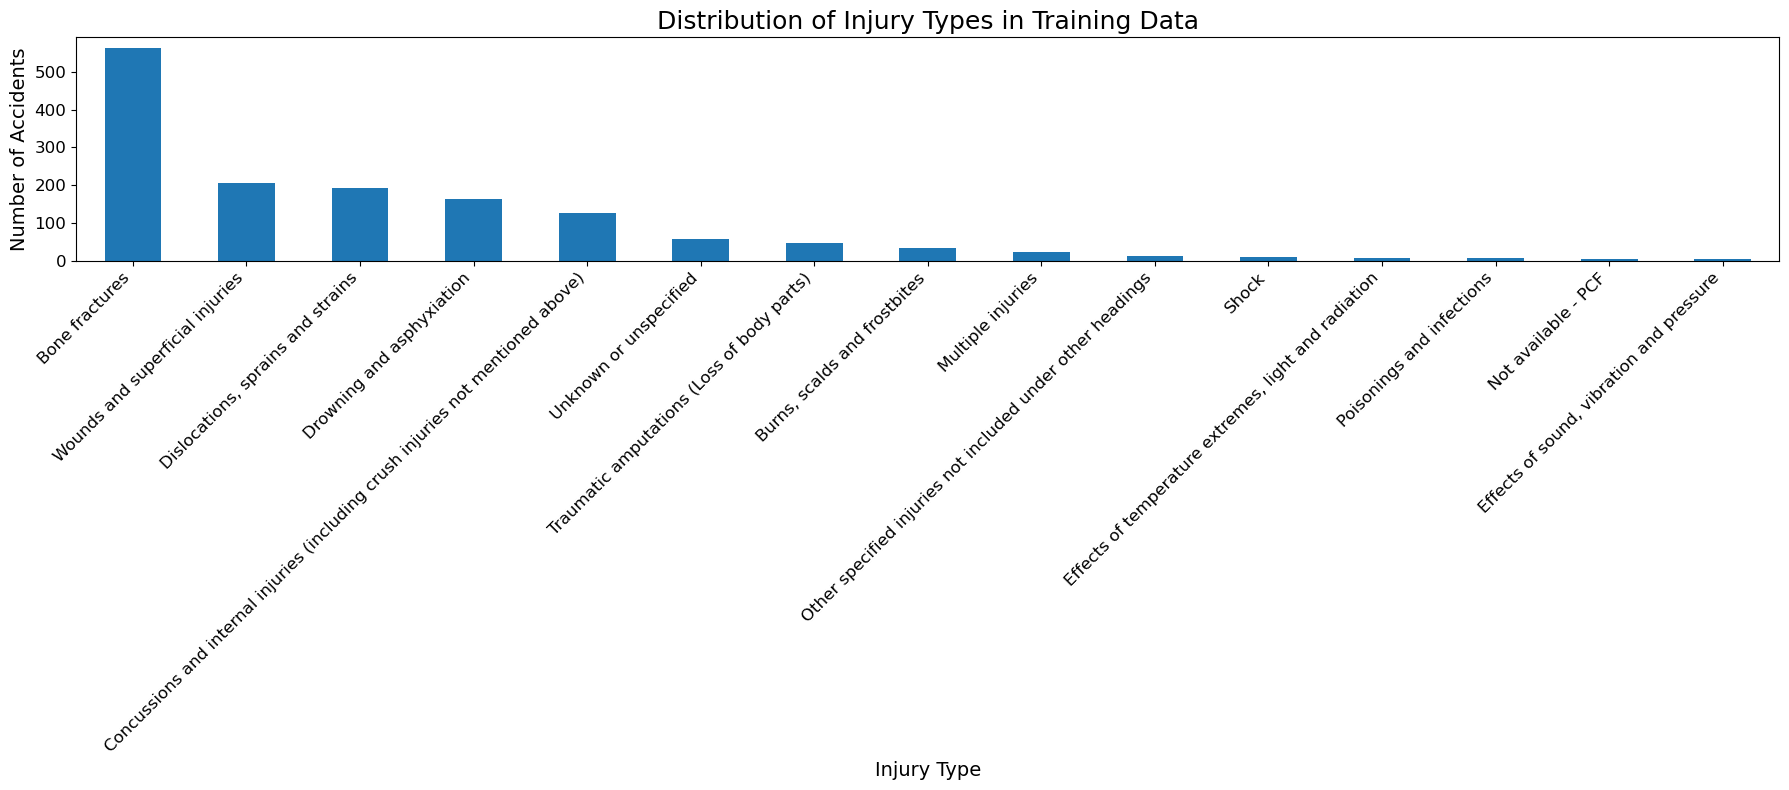

In [8]:
plt.figure(figsize=(18, 8))  

injury_counts = y_train.value_counts()
injury_counts.plot(kind='bar')

plt.title('Distribution of Injury Types in Training Data', fontsize=18)
plt.xlabel('Injury Type', fontsize=14)
plt.ylabel('Number of Accidents', fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig("injury_type_distribution.png")
plt.show()


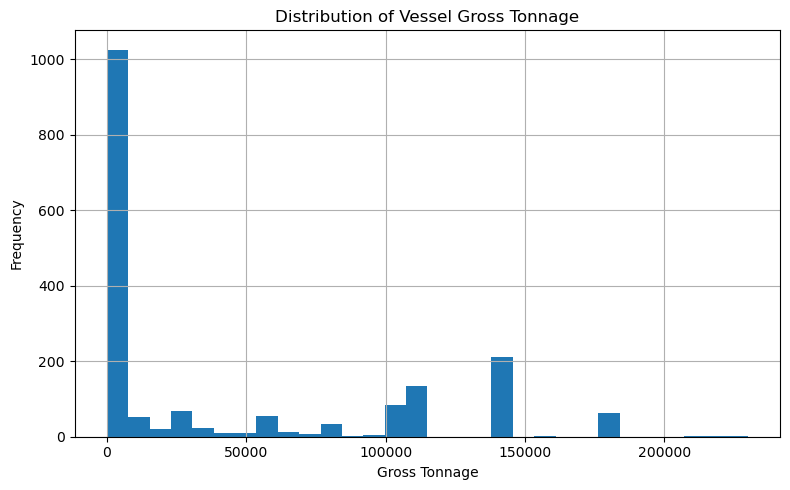

In [9]:
plt.figure(figsize=(8, 5))
df_model['gross_tonnage'].hist(bins=30)
plt.title('Distribution of Vessel Gross Tonnage')
plt.xlabel('Gross Tonnage')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("Distribution of Vessel Gross Tonnage")
plt.show()


In [10]:
# Define ship size based on median gross tonnage
tonnage_threshold = df_model['gross_tonnage'].median()

df_model['ship_size'] = np.where(
    df_model['gross_tonnage'] <= tonnage_threshold,
    'Small ships',
    'Large ships'
)

tonnage_threshold


C:\Users\RC\AppData\Local\Temp\ipykernel_2628\4133842668.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['ship_size'] = np.where(


3000.0

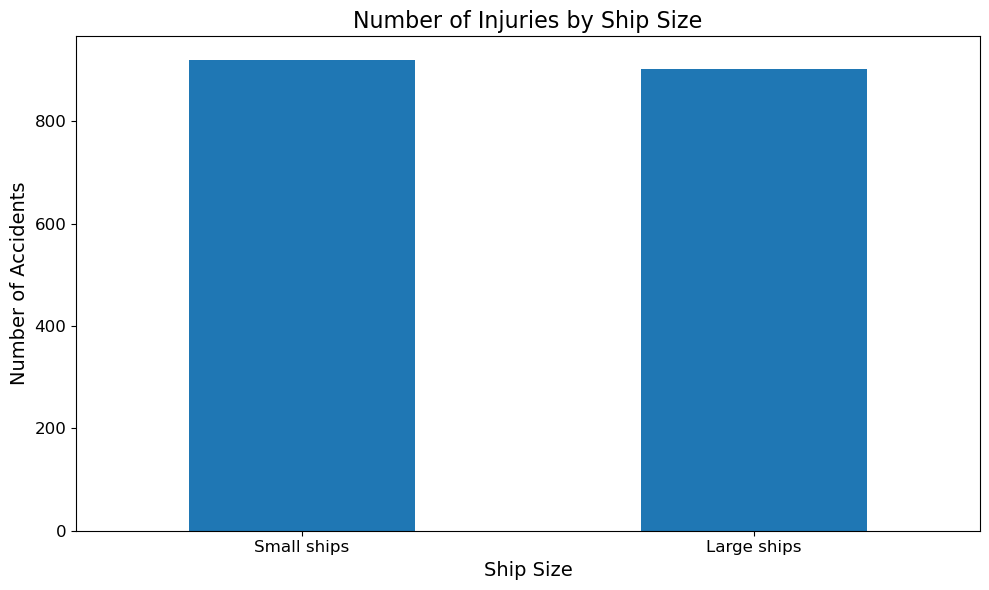

In [11]:
injuries_by_size = df_model['ship_size'].value_counts()

plt.figure(figsize=(10, 6))
injuries_by_size.plot(kind='bar')

plt.title('Number of Injuries by Ship Size', fontsize=16)
plt.xlabel('Ship Size', fontsize=14)
plt.ylabel('Number of Accidents', fontsize=14)

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig("Number of Injuries by Ship Size")
plt.show()


In [12]:
injury_by_size_type = (
    df_model
    .groupby(['ship_size', 'injury_type'])
    .size()
    .unstack(fill_value=0)
)

injury_by_size_type


injury_type,Bone fractures,"Burns, scalds and frostbites",Concussions and internal injuries (including crush injuries not mentioned above),"Dislocations, sprains and strains",Drowning and asphyxiation,"Effects of sound, vibration and pressure","Effects of temperature extremes, light and radiation",Multiple injuries,Not available - PCF,Other specified injuries not included under other headings,Poisonings and infections,Shock,Traumatic amputations (Loss of body parts),Unknown or unspecified,Wounds and superficial injuries
ship_size,,,,,,,,,,,,,,,
Large ships,532,22,41,146,8,3,1,9,4,4,4,4,20,19,86
Small ships,173,19,118,95,196,1,9,20,1,12,5,9,37,54,171


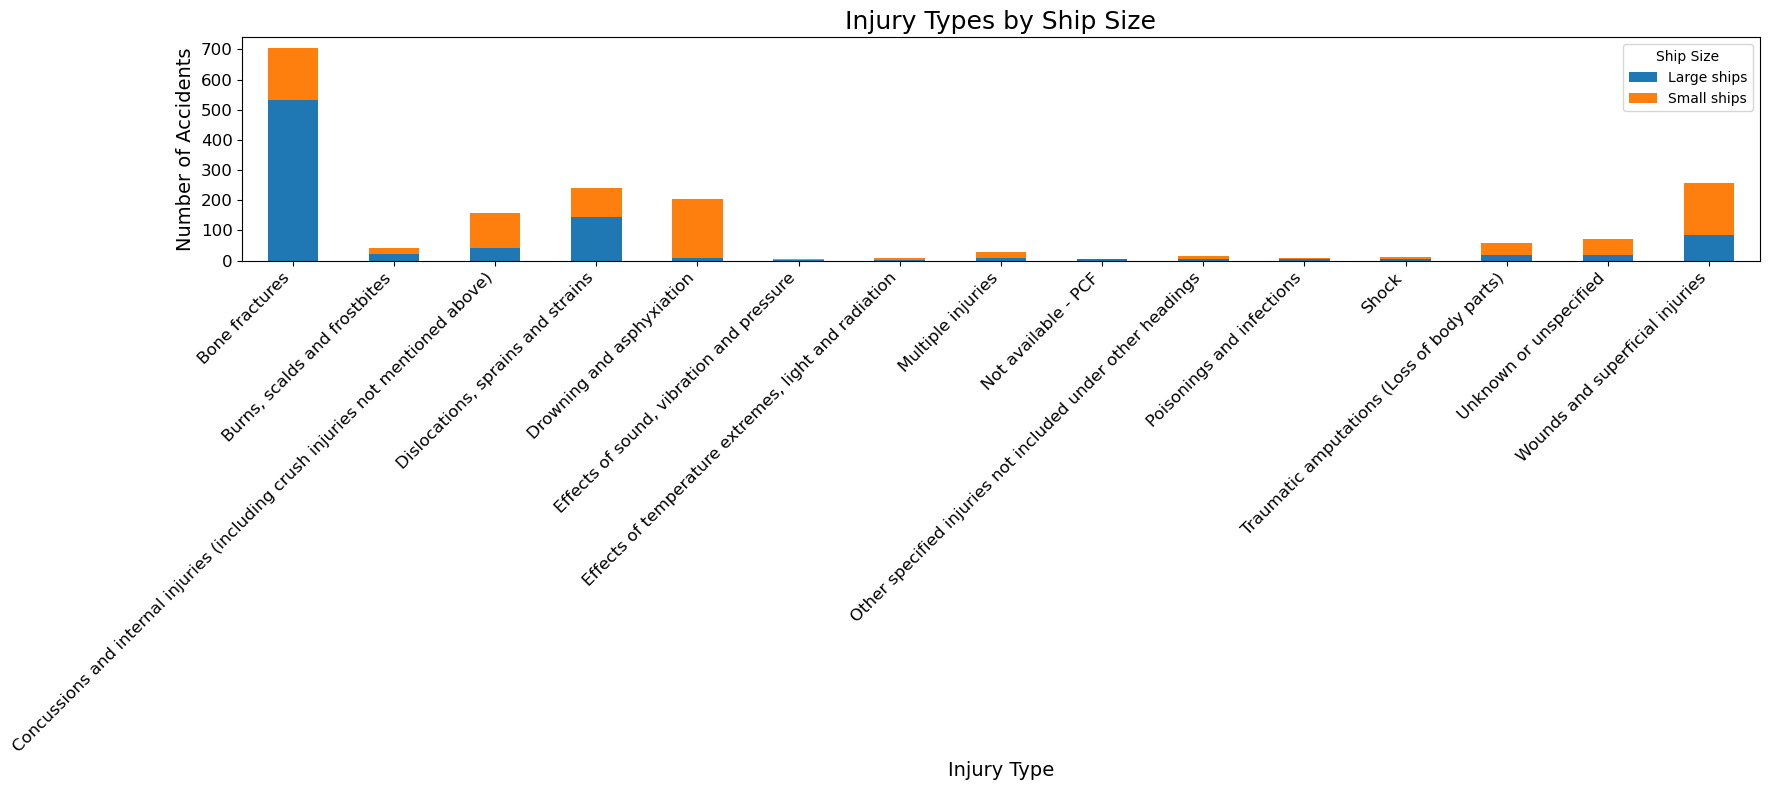

In [13]:
injury_by_size_type.T.plot(
    kind='bar',
    figsize=(18, 8),
    stacked=True
)

plt.title('Injury Types by Ship Size', fontsize=18)
plt.xlabel('Injury Type', fontsize=14)
plt.ylabel('Number of Accidents', fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.legend(title='Ship Size')
plt.tight_layout()
plt.savefig("Injury Types by Ship Size")
plt.show()


Merge Classes and Split Samples

In [14]:
import pandas as pd
import numpy as np

# Remove missing target
df_model = df.dropna(subset=['injury_type']).copy()

# Merge rare classes
class_counts = df_model['injury_type'].value_counts()
rare_classes = class_counts[class_counts < 50].index

df_model['injury_type'] = df_model['injury_type'].apply(
    lambda x: 'Other_Rare_Injuries' if x in rare_classes else x
)

print("Updated class distribution:")
print(df_model['injury_type'].value_counts())

Updated class distribution:
injury_type
Bone fractures                                                                      705
Wounds and superficial injuries                                                     257
Dislocations, sprains and strains                                                   241
Drowning and asphyxiation                                                           204
Concussions and internal injuries (including crush injuries not mentioned above)    159
Other_Rare_Injuries                                                                 127
Unknown or unspecified                                                               73
Traumatic amputations (Loss of body parts)                                           57
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['injury_type'])
y = df_model['injury_type']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])
print("\nTraining distribution:")
print(y_train.value_counts())

Training samples: 1093
Test samples: 730

Training distribution:
injury_type
Bone fractures                                                                      423
Wounds and superficial injuries                                                     154
Dislocations, sprains and strains                                                   145
Drowning and asphyxiation                                                           122
Concussions and internal injuries (including crush injuries not mentioned above)     95
Other_Rare_Injuries                                                                  76
Unknown or unspecified                                                               44
Traumatic amputations (Loss of body parts)                                           34
Name: count, dtype: int64


Data Balancing:

In [16]:
from sklearn.utils import resample

# Combine train data
train_data = X_train.copy()
train_data['injury_type'] = y_train.values

# Separate classes
bone_fractures = train_data[train_data['injury_type'] == 'Bone fractures']
other_classes = train_data[train_data['injury_type'] != 'Bone fractures']

# Downsample Bone fractures to 180 (recommended balanced value)
bone_downsampled = resample(
    bone_fractures,
    replace=False,
    n_samples=180,
    random_state=42
)

# Combine back
train_balanced = pd.concat([bone_downsampled, other_classes])
train_balanced = train_balanced.sample(frac=1, random_state=42)

# Split back
X_train_balanced = train_balanced.drop(columns=['injury_type'])
y_train_balanced = train_balanced['injury_type']

print("Balanced training distribution:")
print(y_train_balanced.value_counts())

Balanced training distribution:
injury_type
Bone fractures                                                                      180
Wounds and superficial injuries                                                     154
Dislocations, sprains and strains                                                   145
Drowning and asphyxiation                                                           122
Concussions and internal injuries (including crush injuries not mentioned above)     95
Other_Rare_Injuries                                                                  76
Unknown or unspecified                                                               44
Traumatic amputations (Loss of body parts)                                           34
Name: count, dtype: int64


In [17]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

categorical_features = X_train_balanced.select_dtypes(include=['object']).columns
numerical_features = X_train_balanced.select_dtypes(include=['int64','float64']).columns

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train_balanced)
X_test_processed = preprocessor.transform(X_test)

Models Training:

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_processed, y_train_balanced)

y_pred_log = log_model.predict(X_test_processed)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.38904109589041097
                                                                                  precision    recall  f1-score   support

                                                                  Bone fractures       0.65      0.61      0.63       282
Concussions and internal injuries (including crush injuries not mentioned above)       0.19      0.12      0.15        64
                                               Dislocations, sprains and strains       0.20      0.22      0.21        96
                                                       Drowning and asphyxiation       0.31      0.46      0.37        82
                                                             Other_Rare_Injuries       0.14      0.06      0.08        51
                                      Traumatic amputations (Loss of body parts)       0.00      0.00      0.00        23
                                                          Unknown or unspecified       0.00    

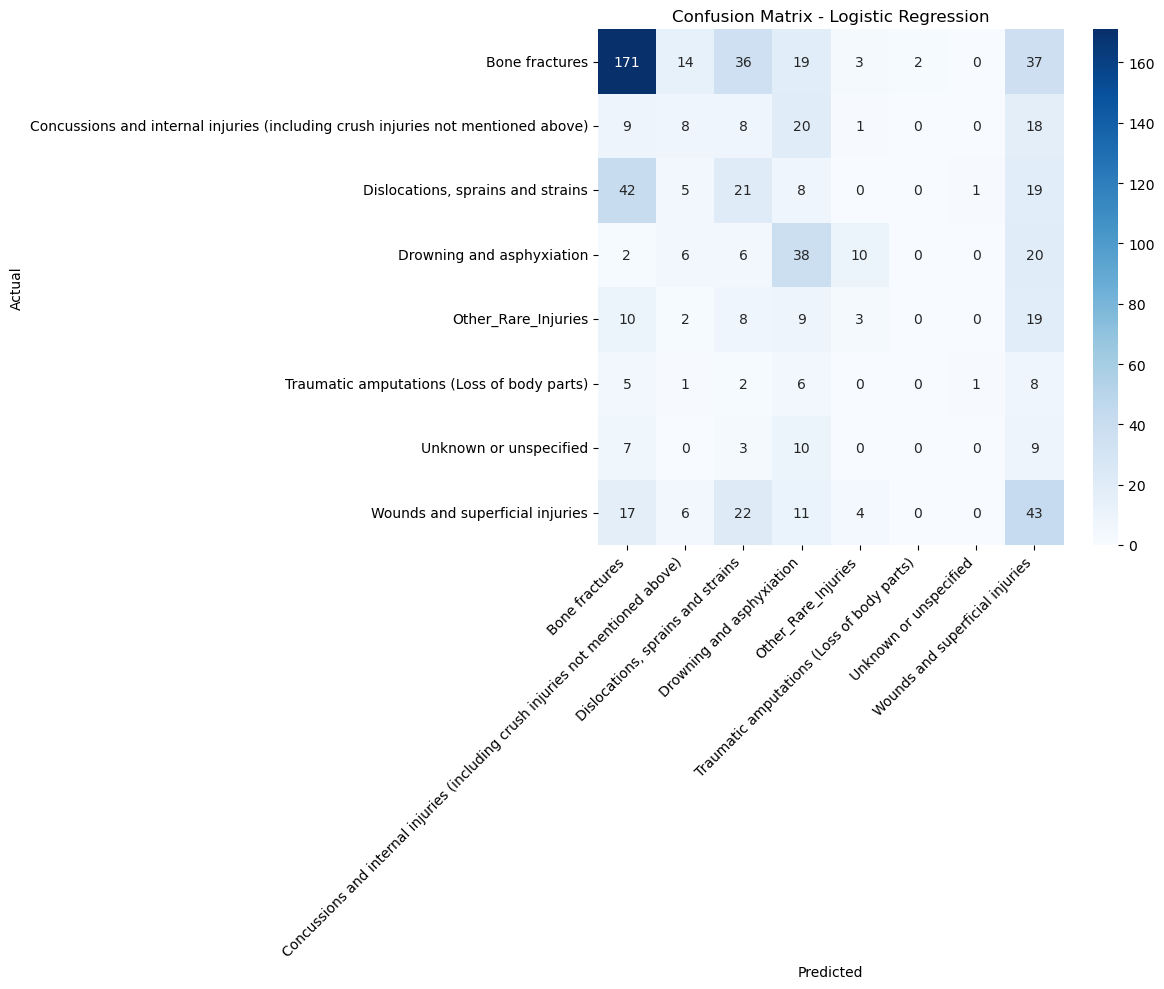

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm_log = confusion_matrix(y_test, y_pred_log)
labels = sorted(y_test.unique())

plt.figure(figsize=(12,10))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("Logistic Regression")
plt.show()


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train_processed, y_train_balanced)

y_pred_rf = rf_model.predict(X_test_processed)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.3150684931506849
                                                                                  precision    recall  f1-score   support

                                                                  Bone fractures       0.60      0.44      0.50       282
Concussions and internal injuries (including crush injuries not mentioned above)       0.16      0.20      0.18        64
                                               Dislocations, sprains and strains       0.17      0.23      0.20        96
                                                       Drowning and asphyxiation       0.41      0.49      0.44        82
                                                             Other_Rare_Injuries       0.12      0.14      0.13        51
                                      Traumatic amputations (Loss of body parts)       0.06      0.04      0.05        23
                                                          Unknown or unspecified       0.06      0.03 

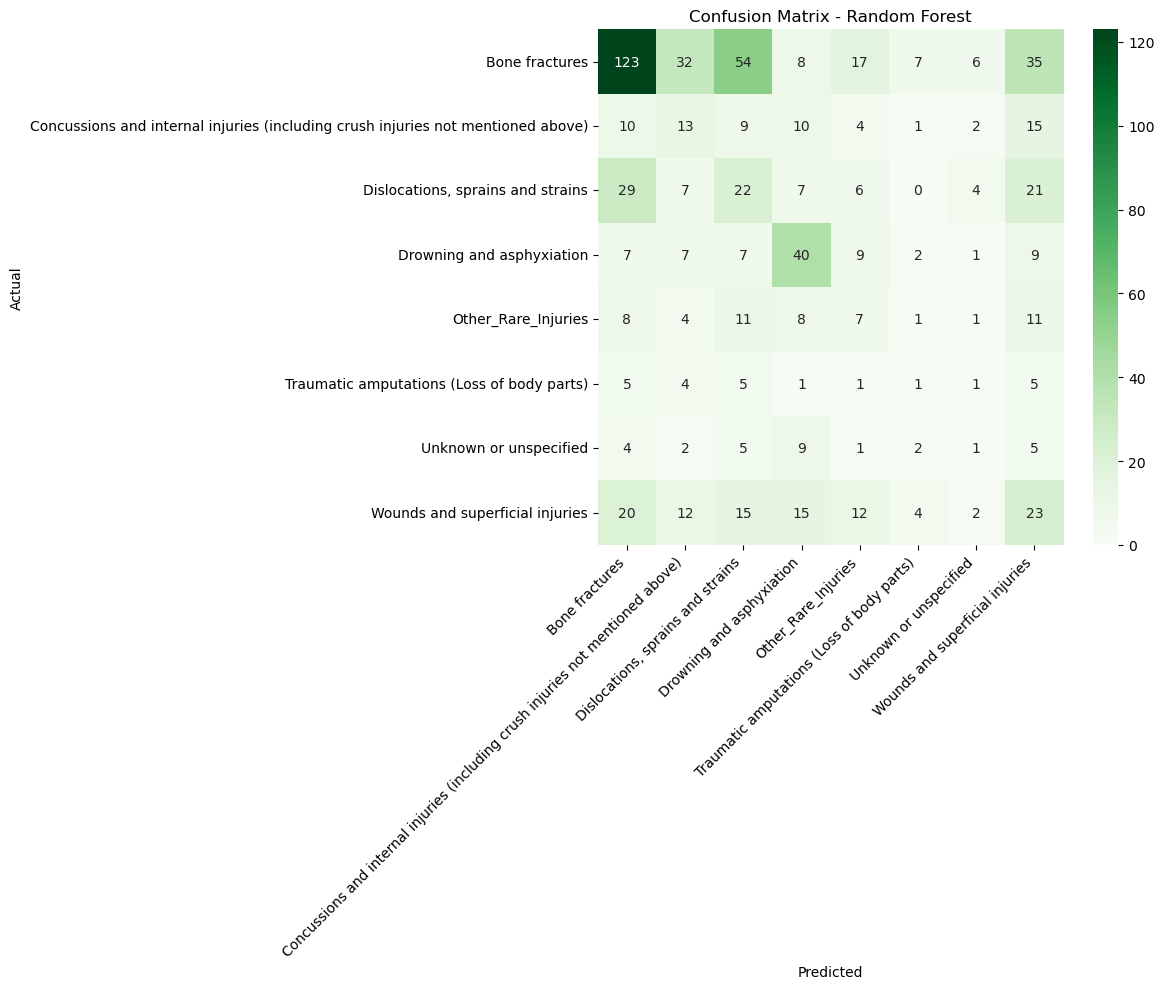

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(12,10))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels,
            yticklabels=labels)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("Random Forest")
plt.show()

In [24]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_processed, y_train_balanced)

y_pred_gb = gb_model.predict(X_test_processed)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.3835616438356164
                                                                                  precision    recall  f1-score   support

                                                                  Bone fractures       0.64      0.56      0.60       282
Concussions and internal injuries (including crush injuries not mentioned above)       0.18      0.14      0.16        64
                                               Dislocations, sprains and strains       0.22      0.19      0.20        96
                                                       Drowning and asphyxiation       0.40      0.51      0.45        82
                                                             Other_Rare_Injuries       0.27      0.16      0.20        51
                                      Traumatic amputations (Loss of body parts)       0.00      0.00      0.00        23
                                                          Unknown or unspecified       0.09      0

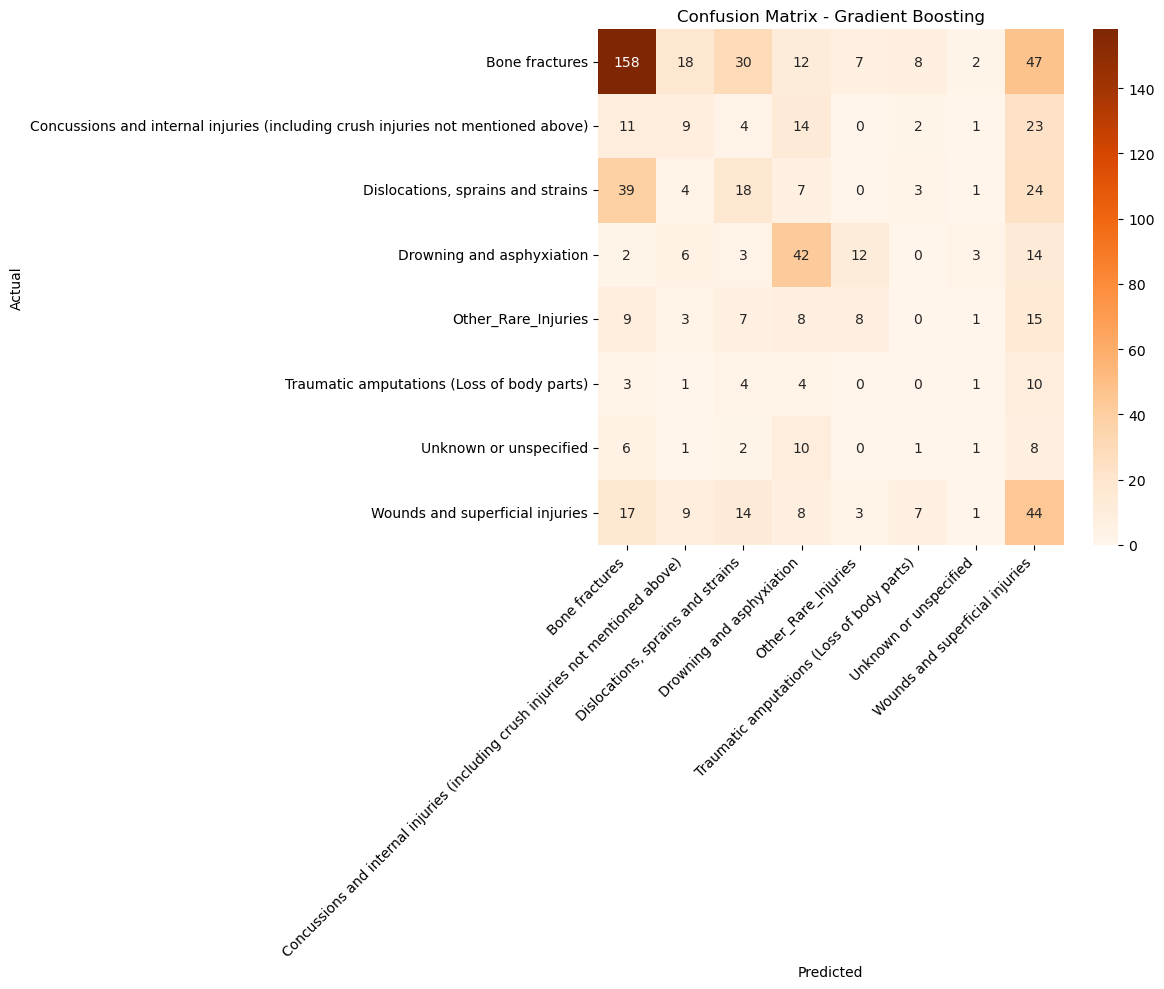

In [25]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(12,10))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels,
            yticklabels=labels)

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("Gradient Boosting")
plt.show()

In [26]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(256,128,64),
    activation='relu',
    max_iter=400,
    random_state=42
)

mlp_model.fit(X_train_processed, y_train_balanced)

y_pred_mlp = mlp_model.predict(X_test_processed)

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

MLP Accuracy: 0.29726027397260274
                                                                                  precision    recall  f1-score   support

                                                                  Bone fractures       0.61      0.35      0.45       282
Concussions and internal injuries (including crush injuries not mentioned above)       0.15      0.08      0.10        64
                                               Dislocations, sprains and strains       0.17      0.26      0.21        96
                                                       Drowning and asphyxiation       0.28      0.55      0.37        82
                                                             Other_Rare_Injuries       0.18      0.18      0.18        51
                                      Traumatic amputations (Loss of body parts)       0.13      0.09      0.11        23
                                                          Unknown or unspecified       0.07      0.03      0.05

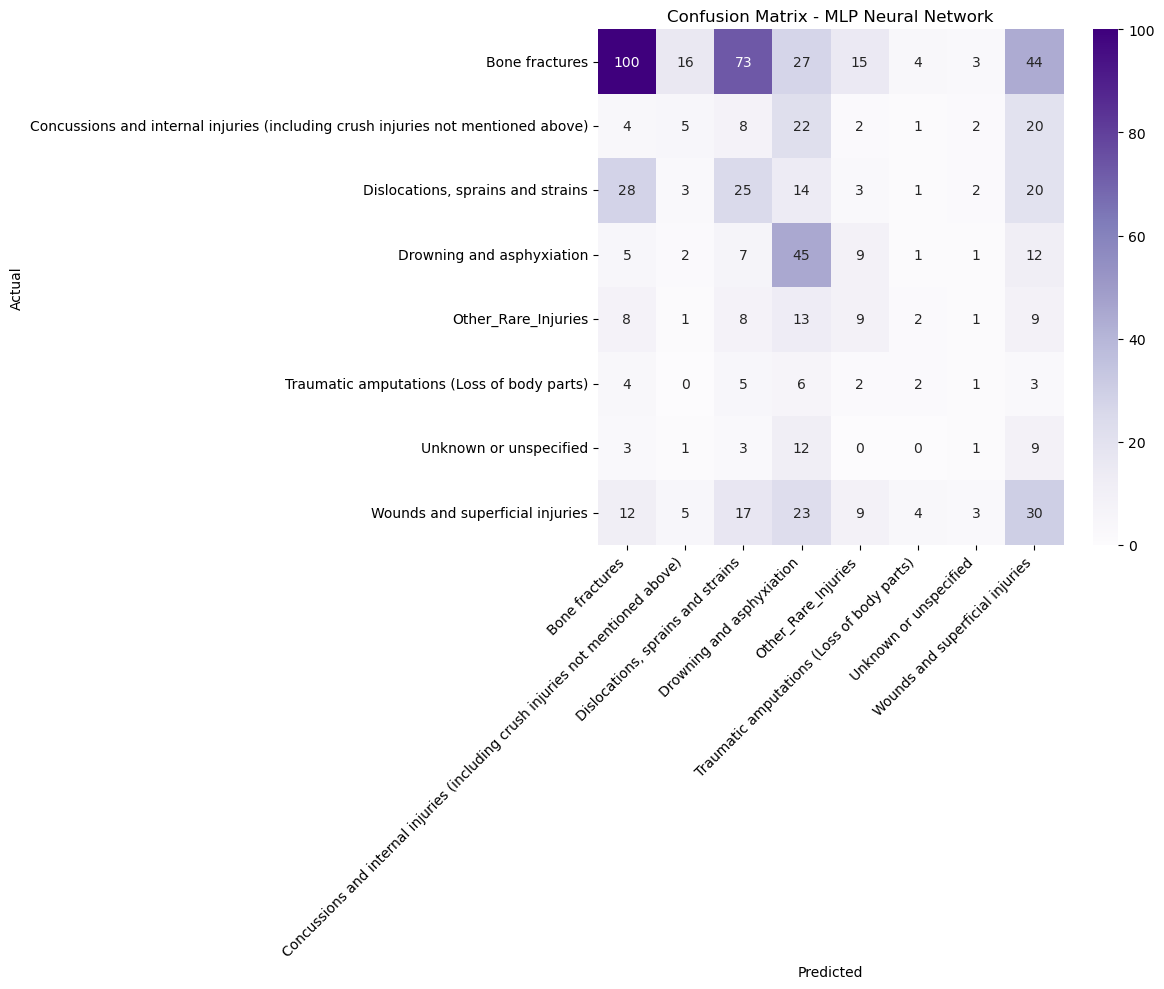

In [27]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(12,10))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels,
            yticklabels=labels)

plt.title("Confusion Matrix - MLP Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("MLP Neural Network")
plt.show()

In [29]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_balanced)
y_test_enc = le.transform(y_test)

num_classes = len(np.unique(y_train_enc))

y_train_cat = to_categorical(y_train_enc, num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes)

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train_processed,
    y_train_cat,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

loss, accuracy = model.evaluate(X_test_processed, y_test_cat)
print("Deep Neural Network Accuracy:", accuracy)

C:\Users\RC\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.2382 - loss: 1.9796 - val_accuracy: 0.3294 - val_loss: 1.8758
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3118 - loss: 1.8091 - val_accuracy: 0.3412 - val_loss: 1.8059
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3338 - loss: 1.7537 - val_accuracy: 0.3176 - val_loss: 1.7949
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3368 - loss: 1.7310 - val_accuracy: 0.3588 - val_loss: 1.7925
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3456 - loss: 1.6995 - val_accuracy: 0.3529 - val_loss: 1.7994
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3485 - loss: 1.6944 - val_accuracy: 0.3588 - val_loss: 1.7966
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3662 - loss: 1.6689 - val_accuracy: 0.3529 - val_loss: 1.7932
Epoch 8/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3721 - loss: 1.6476 - val_accuracy: 0.3529 - v

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


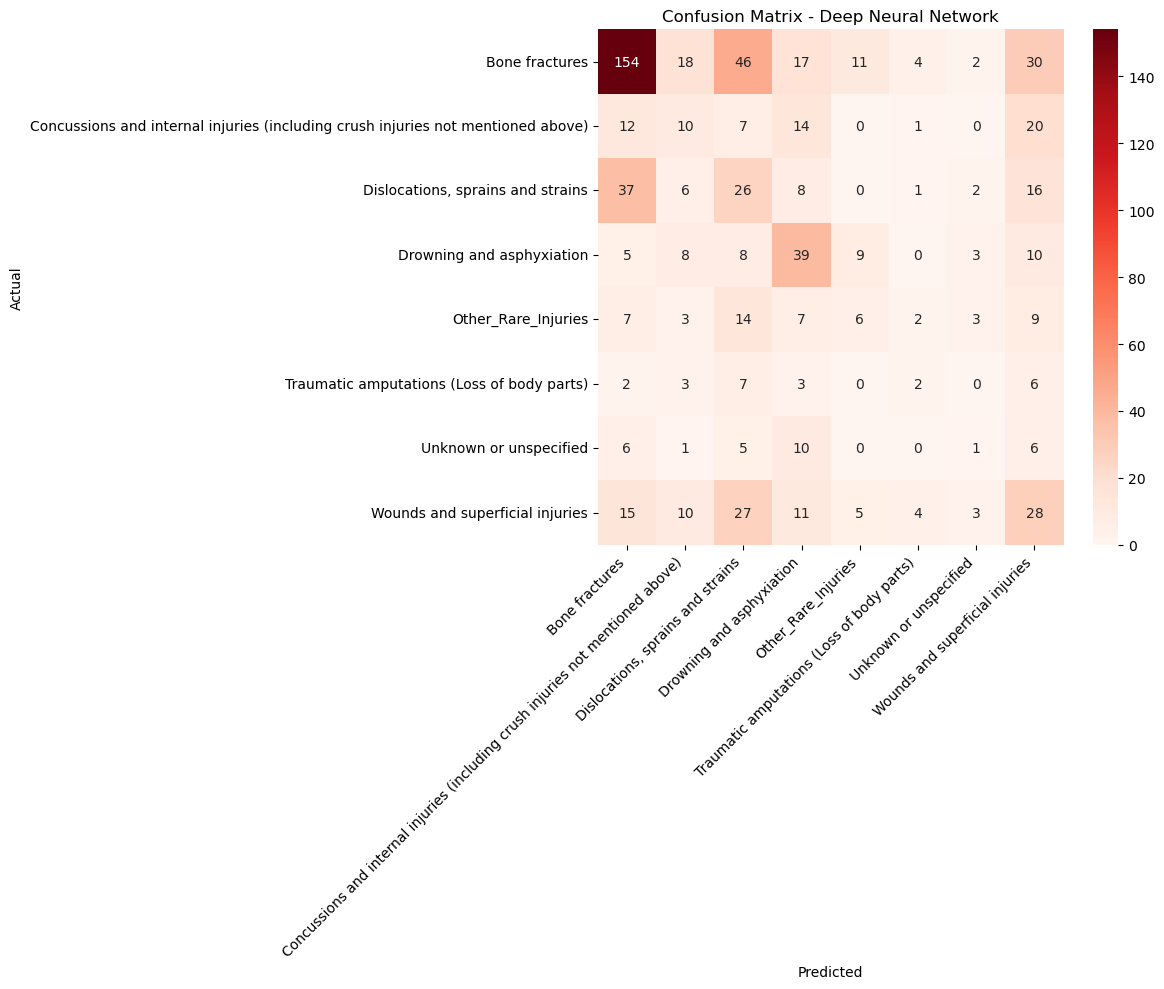

In [30]:
# Predict probabilities
y_pred_dnn_prob = model.predict(X_test_processed)

# Convert probabilities to class labels
y_pred_dnn = np.argmax(y_pred_dnn_prob, axis=1)

# Convert numeric labels back to original
y_pred_dnn_labels = le.inverse_transform(y_pred_dnn)

cm_dnn = confusion_matrix(y_test, y_pred_dnn_labels)

plt.figure(figsize=(12,10))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Reds',
            xticklabels=labels,
            yticklabels=labels)

plt.title("Confusion Matrix - Deep Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("Deep Neural Network")
plt.show()

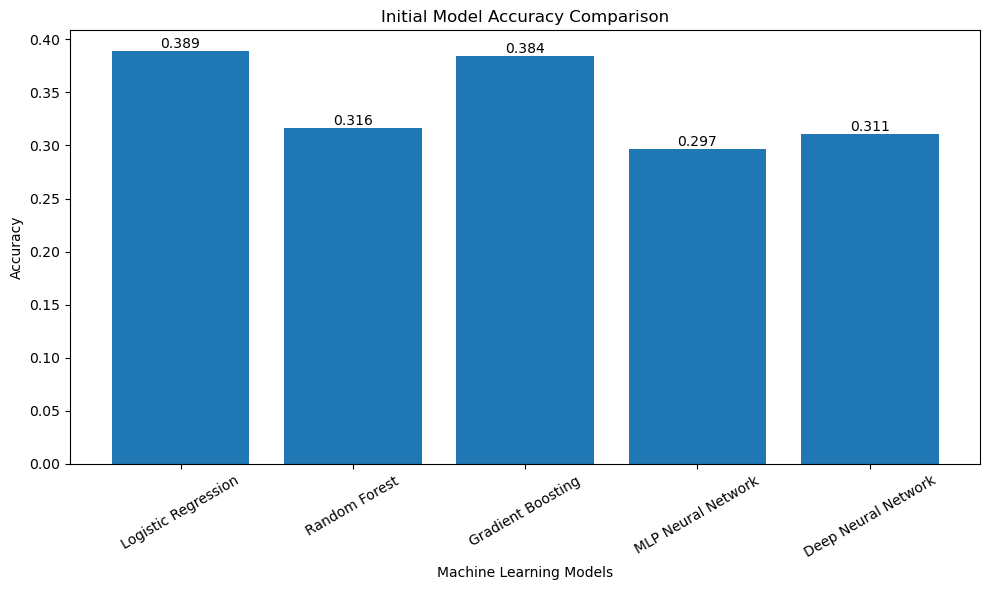

In [32]:
log_acc = 0.389
rf_acc = 0.316
gb_acc = 0.384
mlp_acc = 0.297
dnn_acc = 0.311

import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting",
    "MLP Neural Network",
    "Deep Neural Network"
]

accuracies = [log_acc, rf_acc, gb_acc, mlp_acc, dnn_acc]

plt.figure(figsize=(10,6))

bars = plt.bar(models, accuracies)

plt.title("Initial Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             round(height,3),
             ha='center',
             va='bottom')

plt.tight_layout()
plt.savefig("Comparison")
plt.show()

Hyperparameter Tuning:

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)

param_grid_log = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'saga']
}

grid_log = GridSearchCV(
    log_model,
    param_grid_log,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_log.fit(X_train_processed, y_train_balanced)

print("Best Logistic Regression parameters:", grid_log.best_params_)

best_log_model = grid_log.best_estimator_

Best Logistic Regression parameters: {'C': 0.1, 'solver': 'lbfgs'}


In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [200, 300, 400],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    rf_model,
    param_grid_rf,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_rf.fit(X_train_processed, y_train_balanced)

print("Best Random Forest parameters:", grid_rf.best_params_)

best_rf_model = grid_rf.best_estimator_

Best Random Forest parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}


In [35]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(
    gb_model,
    param_grid_gb,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_gb.fit(X_train_processed, y_train_balanced)

print("Best Gradient Boosting parameters:", grid_gb.best_params_)

best_gb_model = grid_gb.best_estimator_

Best Gradient Boosting parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


In [36]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(max_iter=500)

param_grid_mlp = {
    'hidden_layer_sizes': [(128,64), (256,128,64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001],
    'learning_rate': ['constant', 'adaptive']
}

grid_mlp = GridSearchCV(
    mlp_model,
    param_grid_mlp,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_mlp.fit(X_train_processed, y_train_balanced)

print("Best MLP parameters:", grid_mlp.best_params_)

best_mlp_model = grid_mlp.best_estimator_

Best MLP parameters: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (128, 64), 'learning_rate': 'adaptive'}


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_processed,
    y_train_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

C:\Users\RC\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.2485 - loss: 1.9702 - val_accuracy: 0.3294 - val_loss: 1.8487
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3235 - loss: 1.7913 - val_accuracy: 0.3588 - val_loss: 1.8007
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3294 - loss: 1.7469 - val_accuracy: 0.3294 - val_loss: 1.7899
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3338 - loss: 1.7515 - val_accuracy: 0.3706 - val_loss: 1.7862
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3324 - loss: 1.7160 - val_accuracy: 0.3588 - val_loss: 1.7834
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3485 - loss: 1.7087 - val_accuracy: 0.3294 - val_loss: 1.7855
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3735 - loss: 1.6770 - val_accuracy: 0.3529 - val_loss: 1.7858
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3309 - loss: 1.6750 - val_accuracy: 0.3529 - v

Evaluation of Tuned Models:

In [38]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_log = best_log_model.predict(X_test_processed)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.40136986301369865
                                                                                  precision    recall  f1-score   support

                                                                  Bone fractures       0.65      0.64      0.65       282
Concussions and internal injuries (including crush injuries not mentioned above)       0.23      0.09      0.13        64
                                               Dislocations, sprains and strains       0.20      0.17      0.18        96
                                                       Drowning and asphyxiation       0.32      0.49      0.39        82
                                                             Other_Rare_Injuries       1.00      0.02      0.04        51
                                      Traumatic amputations (Loss of body parts)       0.00      0.00      0.00        23
                                                          Unknown or unspecified       0.00      0.00      0.00    

C:\Users\RC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\RC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\RC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


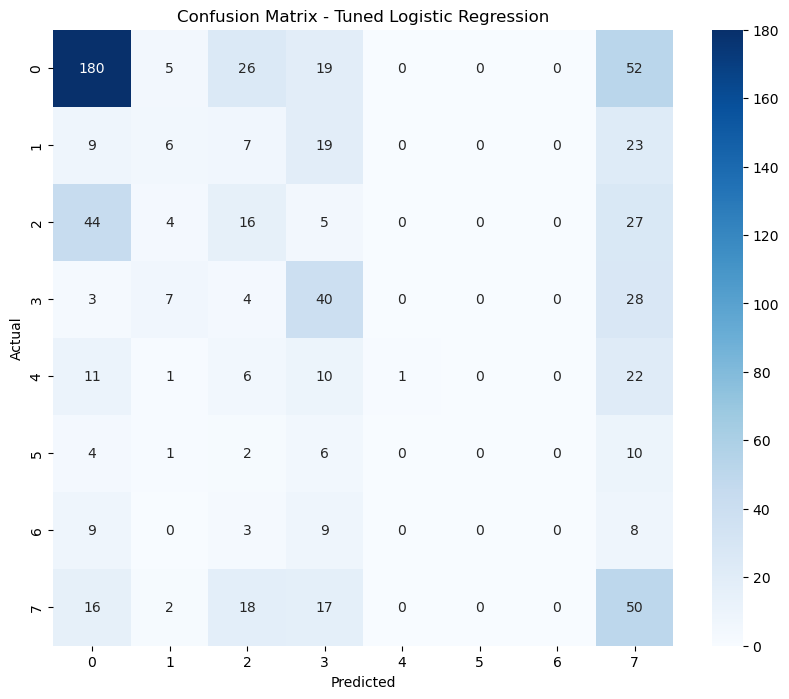

In [44]:
y_pred_log = best_log_model.predict(X_test_processed)

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(10,8))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Tuned Logistic Regression")
plt.show()

In [39]:
from sklearn.metrics import accuracy_score, classification_report

# Predictions
y_pred_rf = best_rf_model.predict(X_test_processed)

# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# Detailed metrics
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.40821917808219177

Classification Report:

                                                                                  precision    recall  f1-score   support

                                                                  Bone fractures       0.65      0.61      0.63       282
Concussions and internal injuries (including crush injuries not mentioned above)       0.15      0.03      0.05        64
                                               Dislocations, sprains and strains       0.21      0.19      0.20        96
                                                       Drowning and asphyxiation       0.39      0.68      0.50        82
                                                             Other_Rare_Injuries       0.30      0.06      0.10        51
                                      Traumatic amputations (Loss of body parts)       0.00      0.00      0.00        23
                                                          Unknown or unspeci

C:\Users\RC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\RC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\RC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


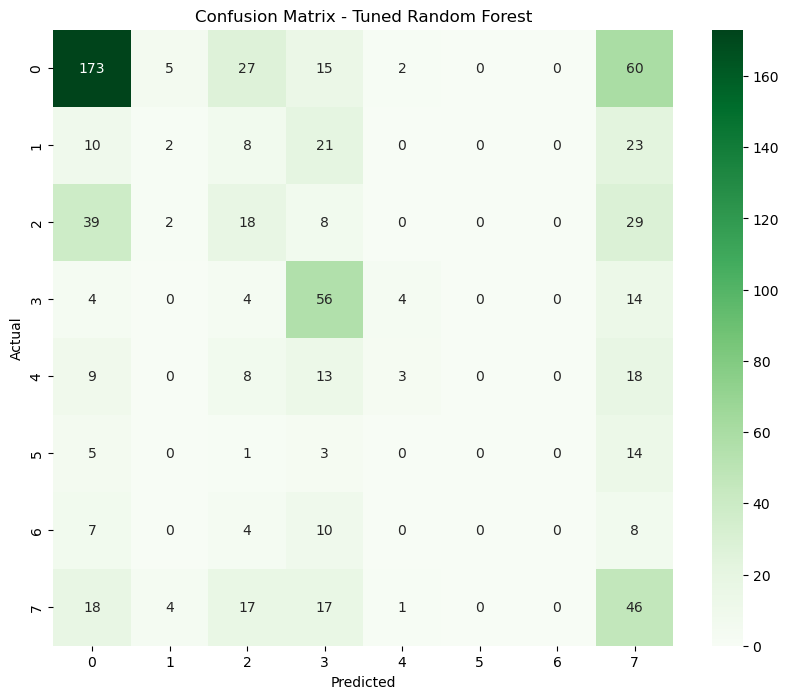

In [45]:
y_pred_rf = best_rf_model.predict(X_test_processed)

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10,8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Tuned Random Forest")
plt.show()

In [40]:
# Predictions
y_pred_gb = best_gb_model.predict(X_test_processed)

# Accuracy
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

# Detailed metrics
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.38904109589041097

Classification Report:

                                                                                  precision    recall  f1-score   support

                                                                  Bone fractures       0.66      0.59      0.62       282
Concussions and internal injuries (including crush injuries not mentioned above)       0.16      0.12      0.14        64
                                               Dislocations, sprains and strains       0.24      0.19      0.21        96
                                                       Drowning and asphyxiation       0.39      0.50      0.44        82
                                                             Other_Rare_Injuries       0.29      0.16      0.20        51
                                      Traumatic amputations (Loss of body parts)       0.00      0.00      0.00        23
                                                          Unknown or uns

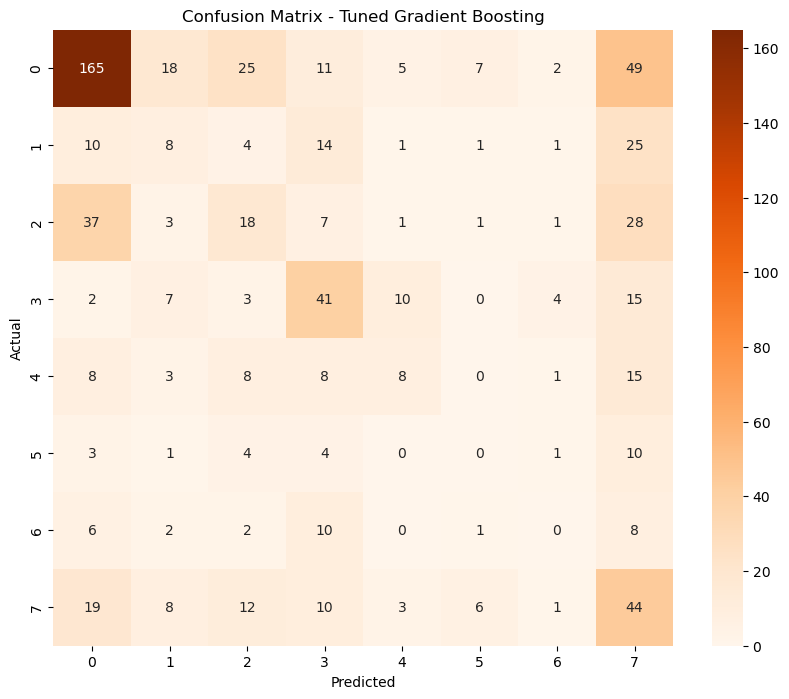

In [46]:
y_pred_gb = best_gb_model.predict(X_test_processed)

cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(10,8))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Tuned Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Tuned Gradient Boosting")
plt.show()

In [41]:
# Predictions
y_pred_mlp = best_mlp_model.predict(X_test_processed)

# Accuracy
print("MLP Neural Network Accuracy:", accuracy_score(y_test, y_pred_mlp))

# Detailed metrics
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_mlp))

MLP Neural Network Accuracy: 0.27808219178082194

Classification Report:

                                                                                  precision    recall  f1-score   support

                                                                  Bone fractures       0.54      0.29      0.37       282
Concussions and internal injuries (including crush injuries not mentioned above)       0.20      0.22      0.21        64
                                               Dislocations, sprains and strains       0.19      0.41      0.25        96
                                                       Drowning and asphyxiation       0.38      0.43      0.40        82
                                                             Other_Rare_Injuries       0.13      0.12      0.12        51
                                      Traumatic amputations (Loss of body parts)       0.12      0.09      0.10        23
                                                          Unknown or un

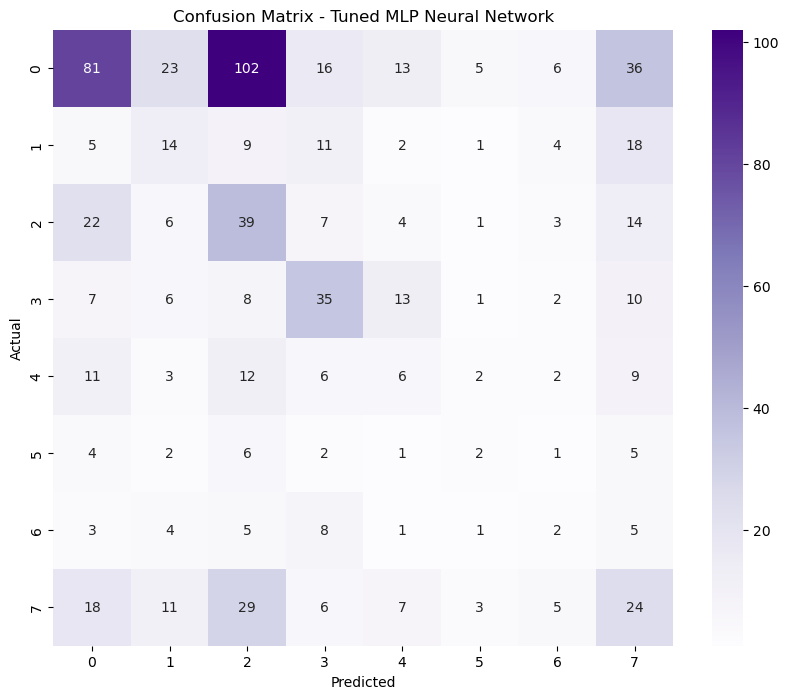

In [47]:
y_pred_mlp = best_mlp_model.predict(X_test_processed)

cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(10,8))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - Tuned MLP Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Tuned MLP Neural Network")
plt.show()

In [42]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Predict probabilities
y_pred_dnn_prob = model.predict(X_test_processed)

# Convert probabilities to class labels
y_pred_dnn = np.argmax(y_pred_dnn_prob, axis=1)

# Convert encoded labels back to original labels
y_pred_dnn_labels = le.inverse_transform(y_pred_dnn)

print("Deep Neural Network Accuracy:", accuracy_score(y_test, y_pred_dnn_labels))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dnn_labels))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Deep Neural Network Accuracy: 0.35342465753424657

Classification Report:

                                                                                  precision    recall  f1-score   support

                                                                  Bone fractures       0.64      0.59      0.61       282
Concussions and internal injuries (including crush injuries not mentioned above)       0.17      0.19      0.18        64
                                               Dislocations, sprains and strains       0.19      0.23      0.21        96
                                                       Drowning and asphyxiation       0.30      0.34      0.32        82
                                                             Other_Rare_Injuries       0.18      0.18      0.18        51
                                      Traumatic amputations (Loss of body parts)       0.14      0.09      0.11        23
                               

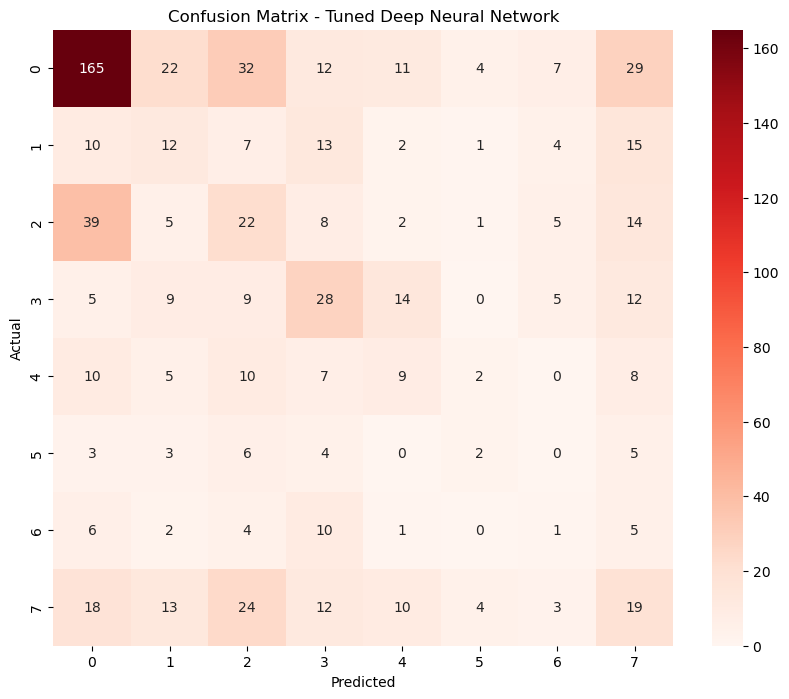

In [48]:
cm_dnn = confusion_matrix(y_test, y_pred_dnn_labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - Tuned Deep Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Tuned Deep Neural Network")
plt.show()

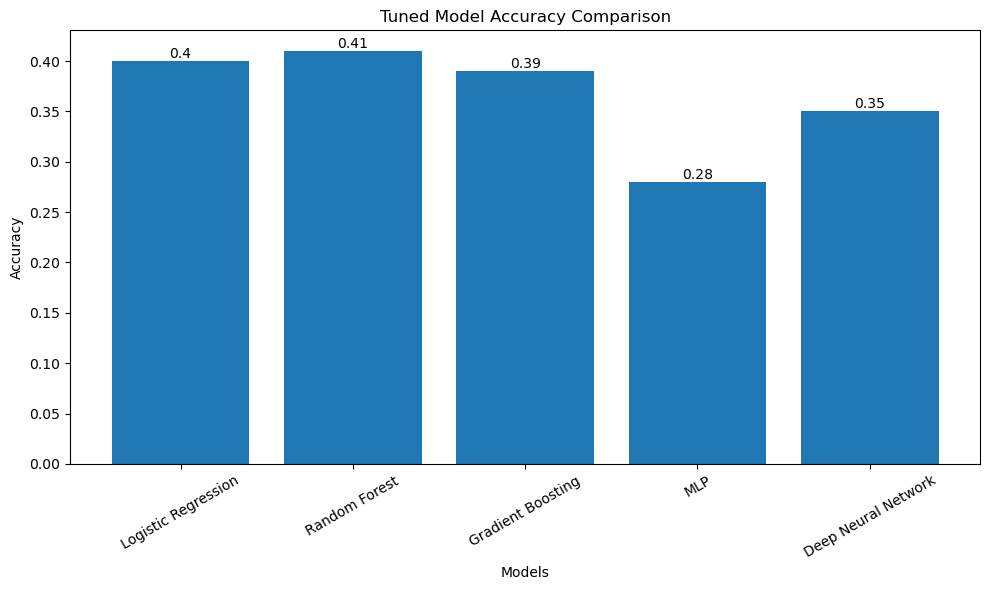

In [50]:
log_tuned = 0.40
rf_tuned = 0.41
gb_tuned = 0.39
mlp_tuned = 0.28
dnn_tuned = 0.35


models = [
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting",
    "MLP",
    "Deep Neural Network"
]

accuracies = [log_tuned, rf_tuned, gb_tuned, mlp_tuned, dnn_tuned]

plt.figure(figsize=(10,6))

bars = plt.bar(models, accuracies)

plt.title("Tuned Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             round(height, 3),
             ha='center',
             va='bottom')

plt.tight_layout()
plt.savefig("Tuned Model Accuracy Comparison")
plt.show()

Baseline vs Tuned Models Comparison:

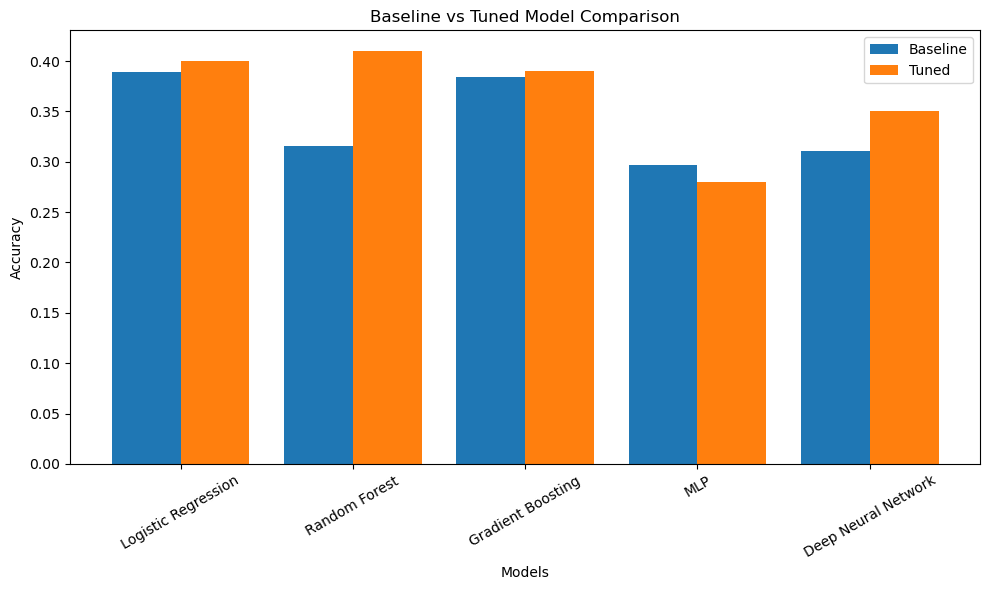

In [51]:
baseline = [0.389, 0.316, 0.384, 0.297, 0.311]
tuned = [0.40, 0.41, 0.39, 0.28, 0.35]

x = range(len(models))

plt.figure(figsize=(10,6))

plt.bar(x, baseline, width=0.4, label='Baseline', align='center')
plt.bar([i + 0.4 for i in x], tuned, width=0.4, label='Tuned', align='center')

plt.xticks([i + 0.2 for i in x], models, rotation=30)

plt.title("Baseline vs Tuned Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("Baseline vs Tuned Model Comparison")
plt.show()